In [5]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [6]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [7]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

In [10]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [11]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
llm=init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B2EFCAECC0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B2EFDF7530>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

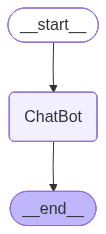

In [13]:
graph=StateGraph(State)

## node
graph.add_node("ChatBot",chatbot)
## Edges

graph.add_edge(START,"ChatBot")
graph.add_edge("ChatBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [17]:
## Invocation

config = {"configurable": {"thread_id": "123"}}

graph_builder.invoke({'messages':"Hi,My name is Geeta And I like painting"},config)

{'messages': [HumanMessage(content='Hi,My name is Geeta And I like painting', additional_kwargs={}, response_metadata={}, id='f6be4993-9379-43c1-9bae-0336bb2bd1d6'),
  AIMessage(content="Nice to meet you, Geeta! Painting is a wonderful hobby, and I'm sure you must have a creative side. What kind of paintings do you like to do? Are you more into watercolors, acrylics, or oils?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 46, 'total_tokens': 95, 'completion_time': 0.058980542, 'completion_tokens_details': None, 'prompt_time': 0.002141769, 'prompt_tokens_details': None, 'queue_time': 0.005312127, 'total_time': 0.061122311}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d805b-8428-7993-bb54-cc21f9b9448b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_toke

#Streaming
Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

values : This streams the full state of the graph after each node is called.
updates : This streams updates to the state of the graph after each node is called.

In [18]:
# Create a thread
config = {"configurable": {"thread_id": "4444"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Geeta And I like painting"},config,stream_mode="updates"):
    print(chunk)

{'ChatBot': {'messages': [AIMessage(content="Nice to meet you, Geeta. It's great to hear that you like painting. What kind of painting do you enjoy the most? Are you into watercolors, acrylics, or oil paints? Do you have a favorite subject or theme that you like to paint?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 46, 'total_tokens': 102, 'completion_time': 0.068171728, 'completion_tokens_details': None, 'prompt_time': 0.002825405, 'prompt_tokens_details': None, 'queue_time': 0.005893492, 'total_time': 0.070997133}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d8063-507e-7761-8849-5a07c05d8a5e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 56, 'total_tokens': 102})]}}


In [21]:
# same Thread and update again 
# and u can see the updated response with the new message in the same thread

for chunk in graph_builder.stream({'messages':"I like reading book and making youtube videos."},config,stream_mode="updates"):
    print(chunk)

{'ChatBot': {'messages': [AIMessage(content='It seems like you have a clear appreciation for reading and creating content on YouTube. If you\'re not planning to monetize your channel, that\'s perfectly fine - creating content can be a great way to express yourself and share your interests with others.\n\nIf you\'re looking for inspiration or ideas for your YouTube channel, you could try exploring book-related content, such as:\n\n- Book reviews\n- Book-inspired art or crafts\n- Author interviews\n- Book club discussions\n- "A day in the life" vlogs about your reading habits\n\nOr, if you\'d like to focus on your art, you could try creating:\n\n- Time-lapse videos of your painting process\n- Step-by-step tutorials on specific techniques\n- Art challenges or prompts\n- Vlogs about your artistic journey\n\nWhat do you think? Is there a particular direction you\'d like to take your YouTube channel?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 178, 'prompt

In [26]:
#create a thread and use values uses in the response
config = {"configurable": {"thread_id": "new-thread-abcd"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Geeta And I like painting"},config,stream_mode="values"):
    print(chunk)


{'messages': [HumanMessage(content='Hi,My name is Geeta And I like painting', additional_kwargs={}, response_metadata={}, id='6de7403b-2503-4582-aac6-acd80e1afe8c')]}
{'messages': [HumanMessage(content='Hi,My name is Geeta And I like painting', additional_kwargs={}, response_metadata={}, id='6de7403b-2503-4582-aac6-acd80e1afe8c'), AIMessage(content="Nice to meet you, Geeta. It's great to hear that you like painting. What kind of paintings do you enjoy creating? Are you more of a landscape, portrait, or abstract artist? Do you have a favorite medium, such as watercolor, oil, or acrylic?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 46, 'total_tokens': 104, 'completion_time': 0.117252271, 'completion_tokens_details': None, 'prompt_time': 0.010576557, 'prompt_tokens_details': None, 'queue_time': 0.216184219, 'total_time': 0.127828828}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_dem

In [27]:
# same Thread and update again 

for chunk in graph_builder.stream({'messages':"I like reading book and making youtube videos."},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Geeta And I like painting', additional_kwargs={}, response_metadata={}, id='6de7403b-2503-4582-aac6-acd80e1afe8c'), AIMessage(content="Nice to meet you, Geeta. It's great to hear that you like painting. What kind of paintings do you enjoy creating? Are you more of a landscape, portrait, or abstract artist? Do you have a favorite medium, such as watercolor, oil, or acrylic?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 46, 'total_tokens': 104, 'completion_time': 0.117252271, 'completion_tokens_details': None, 'prompt_time': 0.010576557, 'prompt_tokens_details': None, 'queue_time': 0.216184219, 'total_time': 0.127828828}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d8069-fbfe-7f41-9cc0-122dce74cc0f-0', tool_calls=[], invalid_tool_calls=[], 

In [29]:
# Use astream_events to get the events of the graph execution in a stream
config = {"configurable": {"thread_id": "async-thread-1234"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Geeta and I like painting"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Geeta and I like painting']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019d806c-8988-7071-ab64-7d33644b4964', 'metadata': {'thread_id': 'async-thread-1234', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Geeta and I like painting', additional_kwargs={}, response_metadata={}, id='359ae5a8-54de-4a6f-a54a-ca8124254930')]}}, 'name': 'ChatBot', 'tags': ['graph:step:1'], 'run_id': '019d806c-898a-7b91-8d73-569a1f56790f', 'metadata': {'thread_id': 'async-thread-1234', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'ChatBot', 'langgraph_triggers': ('branch:to:ChatBot',), 'langgraph_path': ('__pregel_pull', 'ChatBot'), 'langgraph_checkpoint_ns': 'ChatBot:e338b548-6b9a-09ac-bff7-715454724019'}, 'parent_ids': ['019d806c-8988-7071-ab64-7d33644b4964']}
{'event': 'on_chat_model_start', 'data': {'input':